# 1. Load VED and segment into microtrips

This notebook shows the smallest useful workflow: read one week of VED data, pick one trip, clean it, and split it into microtrips.

**Before running this notebook**, download VED from https://github.com/gsoh/VED (see `Data/` in that repository) and extract `VED_DynamicData_Part1.7z` and `Part2.7z`. Point `VED_CSV_PATH` below at one of the extracted `VED_mmddyy_week.csv` files.

In [1]:
VED_CSV_PATH = "VED_171101_week.csv"  # change to your extracted file

In [2]:
from drivecycle_stats.io_ved import (
    clean_trip,
    iter_ved_trips,
    load_ved_dynamic_csv,
)
from drivecycle_stats.segment import segment_microtrips

raw = load_ved_dynamic_csv(VED_CSV_PATH)
print(f"{len(raw)} raw rows, {raw['VehId'].nunique()} vehicles")

489414 raw rows, 258 vehicles


Pick the first trip and clean it (resample to 1 Hz, clip acceleration).

In [3]:
veh_id, trip_id, raw_trip = next(iter_ved_trips(raw))
frame, report = clean_trip(raw_trip)
print(f"VehId={veh_id} Trip={trip_id}")
print(report)
frame.head()

VehId=8 Trip=706
{'n_raw_rows': 137, 'n_dropped_missing_speed': 0, 'n_resampled_rows': 135, 'n_accel_clipped': 0, 'dropped_reason': None}


,Speed,Acceleration
0,40.000000,0.000000
1,44.444444,1.234568
2,46.800000,0.654321
3,47.428571,0.174603
4,47.904762,0.132275


Split into microtrips: a microtrip runs from one stop to the next.

In [4]:
microtrips, summary = segment_microtrips(frame, min_stop_duration_s=2)
print(f"{len(microtrips)} microtrips")
summary

1 microtrips


,start_idx,end_idx,n_seconds,distance_km
0,0,134,135,2.063999


Plot the trip with microtrip boundaries marked.

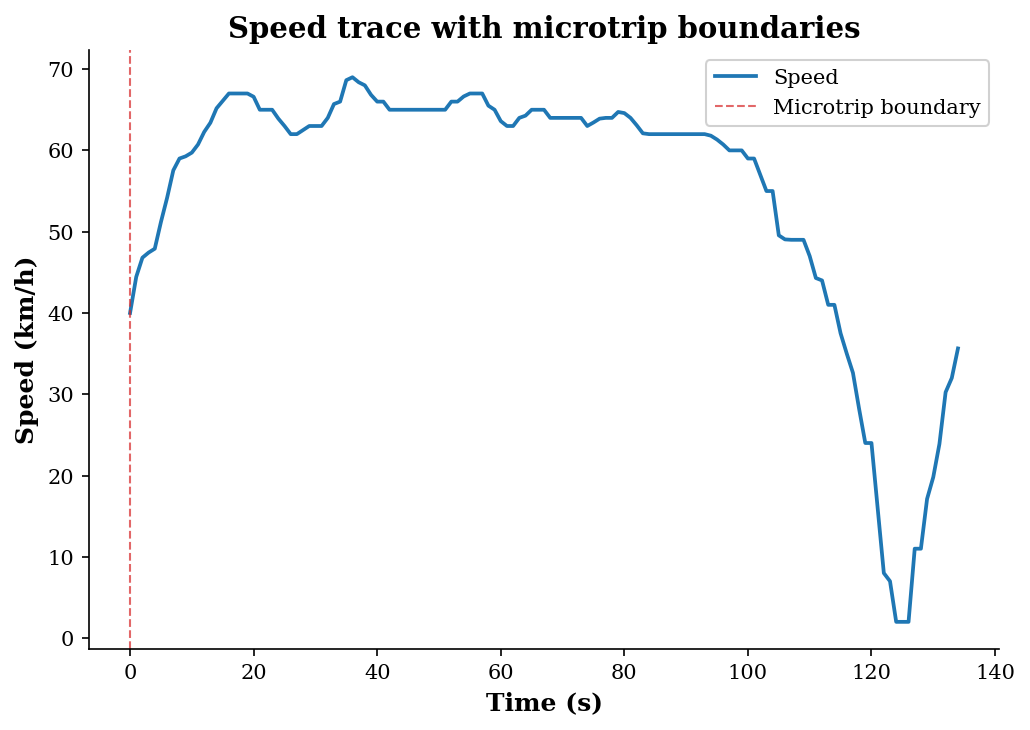

In [5]:
from drivecycle_stats.figures import plot_speed_trace_with_microtrips

fig = plot_speed_trace_with_microtrips(frame, summary)
fig.savefig("01_speed_trace.png", dpi=600, bbox_inches="tight")